# Eksperimen Model Forecasting Inflasi
Notebook ini membandingkan berbagai model Machine Learning untuk melakukan prediksi Inflasi bulanan (MoM).

**Tahapan Utama:**
1. Persiapan Data & Imputasi
2. Pembuatan Fitur (Lag & Windowing)
3. Evaluasi Model (Baseline Linear, Random Forest, Gradient Boosting, dan PyTorch LSTM)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 1. Load Data
Kita menggunakan data `clean_inflasi_ts.csv` yang sebelumnya dibuat.

In [2]:
import os
data_path = os.path.join('..', 'datasets', 'processed', 'clean_inflasi_ts.csv')
df = pd.read_csv(data_path)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)
df.set_index('Tanggal', inplace=True)
print("Shape data:", df.shape)
df.head()


Shape data: (254, 11)


,Inflasi_MoM,IHK,BI_Rate,USD_IDR,Inflasi_Umum_MoM,Inflasi_Inti_MoM,Inflasi_HargaDiatur_MoM,Inflasi_Bergejolak_MoM,Harga_Minyak_USD,Bulan,Tahun
Tanggal,,,,,,,,,,,
2005-01-01,1.43,118.53,7.32,9165.0,NaN,NaN,NaN,NaN,42.97,1,2005
2005-02-01,-0.17,118.33,7.15,9264.5,NaN,NaN,NaN,NaN,44.82,2,2005
2005-03-01,1.91,120.59,8.81,9471.0,NaN,NaN,NaN,NaN,50.94,3,2005
2005-04-01,0.34,121.00,8.12,9570.0,NaN,NaN,NaN,NaN,50.64,4,2005
2005-05-01,0.21,121.25,7.40,9518.0,NaN,NaN,NaN,NaN,47.83,5,2005


## 2. Imputasi Data
Terdapat *missing values* pada data historis:
- **USD/IDR**: Kekosongan wajar yang bisa di-*interpolate* dan di-*forward fill*.
- **IHK**: Setelah 2019 data tidak ada. Kita akan melakukan interpolasi dan forward-fill dengan menambahkan tren inflasi.

In [3]:
# 1. Imputasi USD/IDR (Linear Interpolation)
df['USD_IDR'] = df['USD_IDR'].interpolate(method='linear').ffill().bfill()

# 2. Imputasi IHK (Regresi Sederhana & Cumulative Sum)
df['IHK'] = df['IHK'].interpolate(method='linear').bfill() # isi yg bolong di tengah
last_known_ihk_idx = df['IHK'].dropna().index[-1]

for date in df.loc[df.index > last_known_ihk_idx].index:
    # Perkiraan sederhana IHK bulan ini = IHK bulan lalu * (1 + Inflasi / 100)
    prev_date = date - pd.DateOffset(months=1)
    if prev_date not in df.index:
        prev_date = df.index[df.index.get_loc(date) - 1]
    
    inflasi = df.loc[date, 'Inflasi_MoM']
    df.loc[date, 'IHK'] = df.loc[prev_date, 'IHK'] * (1 + (inflasi / 100))

# Pastikan tidak ada NaN yang tersisa di manapun
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

print("Missing values setelah imputasi:")
print(df.isnull().sum())


Missing values setelah imputasi:
Inflasi_MoM                0
IHK                        0
BI_Rate                    0
USD_IDR                    0
Inflasi_Umum_MoM           0
Inflasi_Inti_MoM           0
Inflasi_HargaDiatur_MoM    0
Inflasi_Bergejolak_MoM     0
Harga_Minyak_USD           0
Bulan                      0
Tahun                      0
dtype: int64


## 3. Pembuatan Fitur (Lag Features)
Untuk memprediksi inflasi, kita harus membuat sekuens historis (misal 12 bulan ke belakang) sebagai variabel prediktor.

In [4]:
# Fitur untuk Machine Learning Klasik (Tabular)
features = ['Inflasi_MoM', 'IHK', 'BI_Rate', 'USD_IDR']
lag_steps = 12

df_ml = df.copy()
feature_cols = []

# Buat Lag Features (t-1 sampai t-12)
for feat in features:
    for i in range(1, lag_steps + 1):
        col_name = f"{feat}_lag{i}"
        df_ml[col_name] = df_ml[feat].shift(i)
        feature_cols.append(col_name)

# Drop baris NaN akibat shifting
df_ml.dropna(inplace=True)

X_tabular = df_ml[feature_cols].values
y_tabular = df_ml['Inflasi_MoM'].values
dates_tabular = df_ml.index

print("Shape Fitur Tabular:", X_tabular.shape)


Shape Fitur Tabular: (242, 48)


## 4. Chronological Train-Test Split

In [5]:
n = len(X_tabular)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X_tabular[:train_end], y_tabular[:train_end]
X_val, y_val = X_tabular[train_end:val_end], y_tabular[train_end:val_end]
X_test, y_test = X_tabular[val_end:], y_tabular[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (169, 48), Val: (36, 48), Test: (37, 48)


## 5. Model 1: Linear Regression (Baseline)

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression -> MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}")


Linear Regression -> MAE: 0.3055, RMSE: 0.4199


## 6. Model 2: Random Forest Regressor

In [7]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")


Random Forest -> MAE: 0.3132, RMSE: 0.4412


## 7. Model 3: Gradient Boosting Regressor

In [8]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting -> MAE: {mae_gb:.4f}, RMSE: {rmse_gb:.4f}")


Gradient Boosting -> MAE: 0.3422, RMSE: 0.4628


## 8. Model 4: PyTorch LSTM
LSTM memerlukan bentuk input 3D: `(batch, sequence_length, features)`. Kita akan menggunakan MinMaxScaler pada fitur numerik.

In [9]:
# Membentuk data 3D untuk LSTM
df_lstm = df.copy()

scaler = MinMaxScaler()
# Fit HANYA pada data train (0 sampai train_end + lag_steps) untuk menghindari leakage
train_limit = train_end + lag_steps
scaler.fit(df_lstm.iloc[:train_limit][features])

df_lstm_scaled = pd.DataFrame(scaler.transform(df_lstm[features]), columns=features, index=df_lstm.index)

def create_lstm_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length]['Inflasi_MoM']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_lstm_sequences(df_lstm_scaled, lag_steps)

X_train_lstm = torch.tensor(X_seq[:train_end], dtype=torch.float32)
y_train_lstm = torch.tensor(y_seq[:train_end], dtype=torch.float32).view(-1, 1)

X_val_lstm = torch.tensor(X_seq[train_end:val_end], dtype=torch.float32)
y_val_lstm = torch.tensor(y_seq[train_end:val_end], dtype=torch.float32).view(-1, 1)

X_test_lstm = torch.tensor(X_seq[val_end:], dtype=torch.float32)
y_test_lstm = torch.tensor(y_seq[val_end:], dtype=torch.float32).view(-1, 1)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel(input_size=4, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# Training loop sederhana
epochs = 50
for epoch in range(epochs):
    lstm_model.train()
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm)
    loss = criterion(outputs, y_train_lstm)
    loss.backward()
    optimizer.step()

lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_test_lstm).numpy()

# Karena target ada di scaler, kita tidak bisa langsung inverting tanpa padding dummy
dummy = np.zeros((len(y_pred_lstm_scaled), 4))
dummy[:, 0] = y_pred_lstm_scaled[:, 0]
y_pred_lstm = scaler.inverse_transform(dummy)[:, 0]

mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"PyTorch LSTM -> MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")


PyTorch LSTM -> MAE: 0.2741, RMSE: 0.4157


## 9. Komparasi Visual Hasil Evaluasi

               Model       MAE      RMSE
3       PyTorch LSTM  0.274096  0.415682
0  Linear Regression  0.305473  0.419904
1      Random Forest  0.313249  0.441200
2  Gradient Boosting  0.342215  0.462807


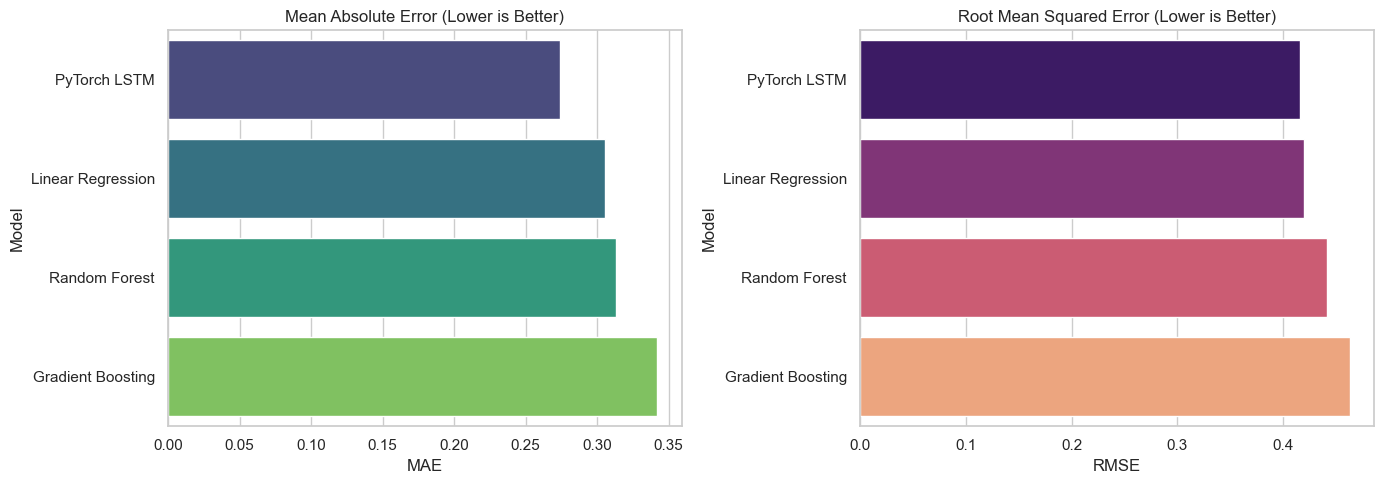

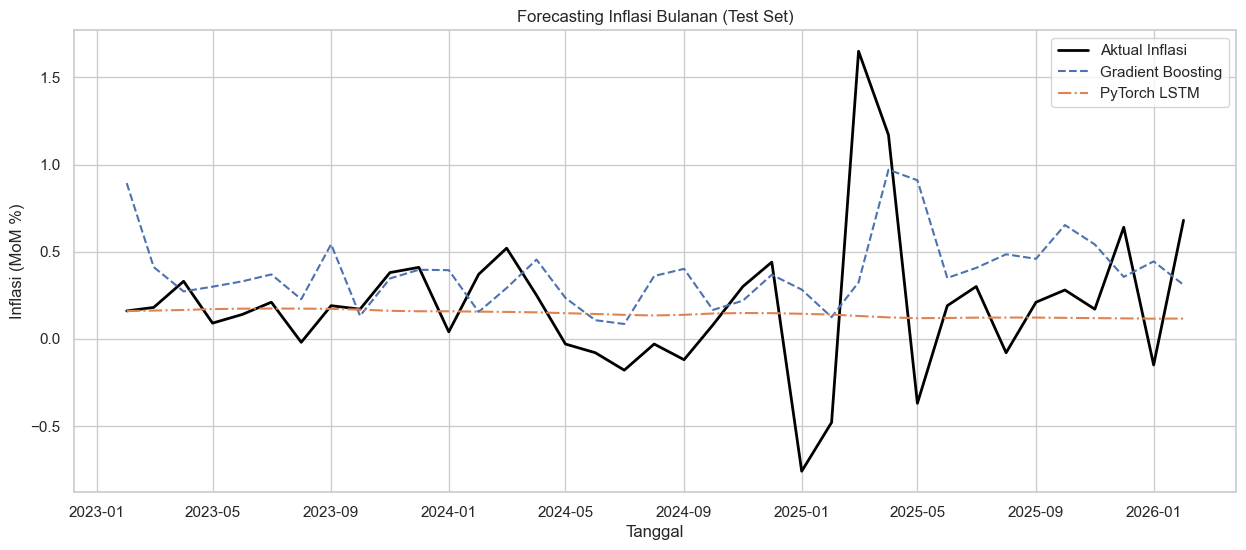

In [10]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'PyTorch LSTM']
mae_scores = [mae_lr, mae_rf, mae_gb, mae_lstm]
rmse_scores = [rmse_lr, rmse_rf, rmse_gb, rmse_lstm]

eval_df = pd.DataFrame({
    'Model': models,
    'MAE': mae_scores,
    'RMSE': rmse_scores
})

print(eval_df.sort_values('MAE'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='MAE', y='Model', data=eval_df.sort_values('MAE'), ax=axes[0], palette='viridis')
axes[0].set_title('Mean Absolute Error (Lower is Better)')

sns.barplot(x='RMSE', y='Model', data=eval_df.sort_values('RMSE'), ax=axes[1], palette='magma')
axes[1].set_title('Root Mean Squared Error (Lower is Better)')

plt.tight_layout()
plt.show()

# Visualisasi Prediksi Waktu Aktual vs Prediksi (Gradient Boosting & LSTM)
plt.figure(figsize=(15, 6))
plt.plot(dates_tabular[val_end:], y_test, label='Aktual Inflasi', color='black', linewidth=2)
plt.plot(dates_tabular[val_end:], y_pred_gb, label='Gradient Boosting', linestyle='--')
plt.plot(dates_tabular[val_end:], y_pred_lstm, label='PyTorch LSTM', linestyle='-.')
plt.title('Forecasting Inflasi Bulanan (Test Set)')
plt.xlabel('Tanggal')
plt.ylabel('Inflasi (MoM %)')
plt.legend()
plt.grid(True)
plt.show()
